# Importing Images

In [1]:
import requests
from PIL import Image
from io import BytesIO
import os

# Output folder
output_folder = "/kaggle/working/"
os.makedirs(output_folder, exist_ok=True)

# Number of images
n = 9

for i in range(1, n + 1):
    url = "https://picsum.photos/300"

    res = requests.get(url)
    img = Image.open(BytesIO(res.content)).convert("RGB")

    save_path = os.path.join(output_folder, f"img{i}.jpg")
    img.save(save_path, "JPEG")

print("Saved 9 images from API to /kaggle/working/")

Saved 9 images from API to /kaggle/working/


# LAB - I

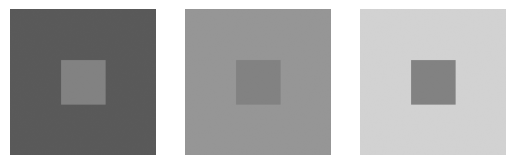

In [2]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

size = (200, 200)
box_coords = (70, 70, 130, 130)
bg_grey_level = [90, 150, 210]

images = []

for bg in bg_grey_level:
  img = Image.new('L', size, color = bg)
  draw = ImageDraw.Draw(img)
  draw.rectangle(box_coords, fill = 130)
  images.append(img)


# Display
fig, axes = plt.subplots(1, 3)
for i in range(0, len(images)):
  axes[i].imshow(images[i], cmap = 'gray', vmin = 0, vmax = 255)
  axes[i].axis('off')

plt.show()

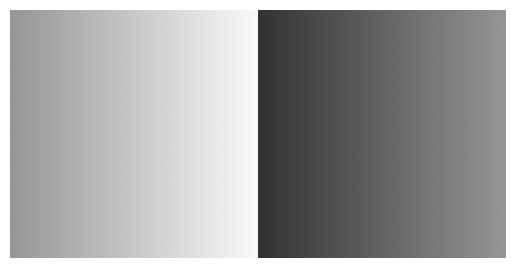

In [3]:
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

W, H = 400, 200
img = Image.new('L', (W, H), 0)
draw = ImageDraw.Draw(img)

half = W // 2

# ----- Left half : 150 -> 250 (left -> right) using line -----
grad_left = np.linspace(150, 250, half).astype(int)
for x in range(half):
  draw.line([(x, 0), (x, H-1)], fill=int(grad_left[x]))

# ----- Right half : 50 -> 150 (left -> right) using line -----
grad_right = np.linspace(50, 150, half).astype(int)
for x in range(half):
  draw.line([(half + x, 0), (half + x, H-1)], fill=int(grad_right[x]))


plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

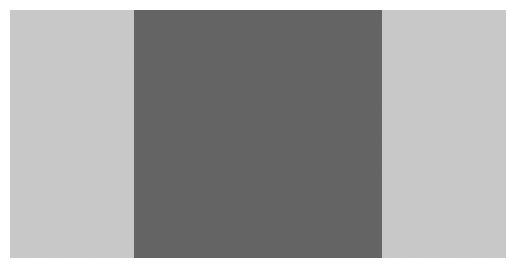

In [4]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

W, H = 400, 200
img = Image.new('L', (W, H), 0)
draw = ImageDraw.Draw(img)

# --- Using line (vertical stripes) ---
# 0–99 : 200
for x in range(0, 100):
  draw.line([(x, 0), (x, H-1)], fill=200)

# 100–299 : 100
for x in range(100, 300):
  draw.line([(x, 0), (x, H-1)], fill=100)

# 300–399 : 200
for x in range(300, 400):
  draw.line([(x, 0), (x, H-1)], fill=200)

plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# LAB - II

Displaying Image of size: 32 x 32


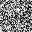

Displaying Image of size: 64 x 64


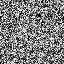

Displaying Image of size: 128 x 128


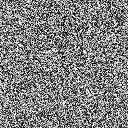

Displaying Image of size: 256 x 256


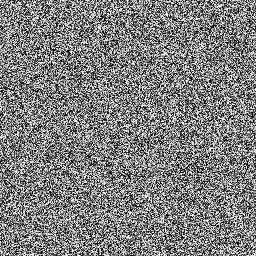

In [5]:
from PIL import Image
import random
from IPython.display import display

img_size = [32, 64, 128, 256]

for imgSize in img_size:
	ni = Image.new(mode='L', size=(imgSize, imgSize))

	for i in range(imgSize):
		for j in range(imgSize):
			gray_level = random.randint(0, 255)
			ni.putpixel((i, j), gray_level)

	print(f"Displaying Image of size: {imgSize} x {imgSize}")
	display(ni)

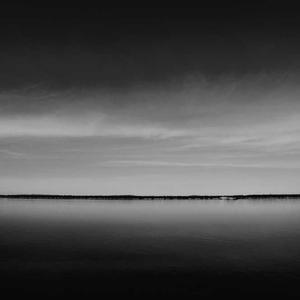

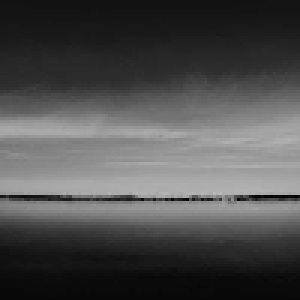

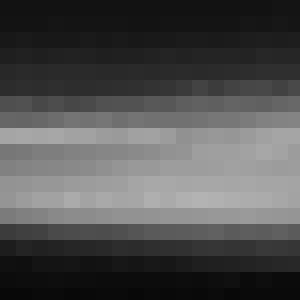

In [6]:
from PIL import Image
from IPython.display import display

img = Image.open("img1.jpg").convert("L")
width, height = img.size

def downsample(step):
	upscaled = Image.new("L", (width, height))

	for y in range(height):
		for x in range(width):
			upscaled.putpixel((x, y), img.getpixel((x // step * step, y // step * step)))

	return upscaled

display(downsample(1))
display(downsample(3))
display(downsample(16))

# LAB - III

### Image 1

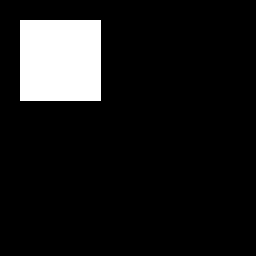

### Image 2

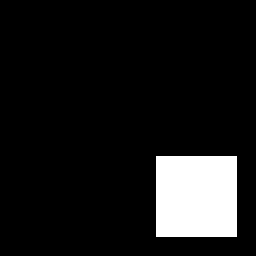

### AND Result

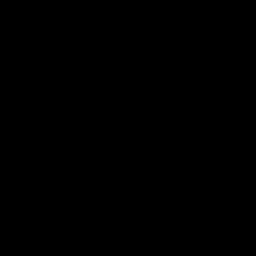

### OR Result

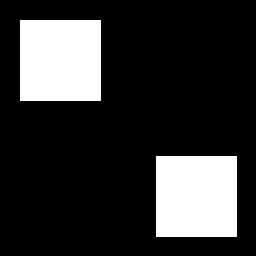

### NOT Result (Image 1)

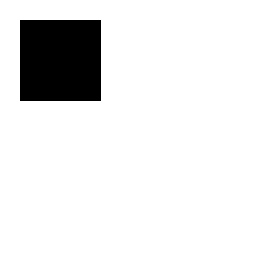

In [7]:
from PIL import Image, ImageDraw
from IPython.display import display, Markdown

img1 = Image.new(mode="L", size=(256, 256))
draw1 = ImageDraw.Draw(img1)
draw1.rectangle([20, 20, 100, 100], fill=255)

img2 = Image.new(mode="L", size=(256, 256))
draw2 = ImageDraw.Draw(img2)
draw2.rectangle([156, 156, 236, 236], fill=255)

width, height = img1.size

and_img = Image.new('L', (width, height))
or_img  = Image.new('L', (width, height))
not_img = Image.new('L', (width, height))

for x in range(width):
	for y in range(height):
		a = img1.getpixel((x, y))
		b = img2.getpixel((x, y))

		and_img.putpixel((x, y), a & b)
		or_img.putpixel((x, y),  a | b)
		not_img.putpixel((x, y), (~a) % 256)

display(Markdown("### Image 1"))
display(img1)
display(Markdown("### Image 2"))
display(img2)
display(Markdown("### AND Result"))
display(and_img)
display(Markdown("### OR Result"))
display(or_img)
display(Markdown("### NOT Result (Image 1)"))
display(not_img)

# LAB - IV

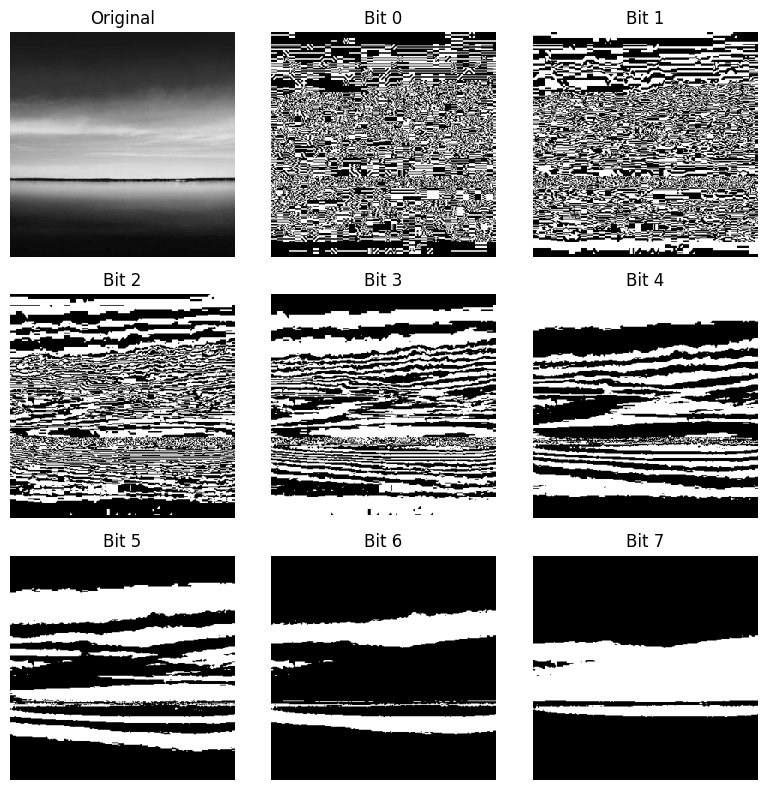

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("img1.jpg").convert("L")
img_np = np.array(img)

bit_planes = []

for b in range(8):
	plane = (img_np >> b) & 1
	bit_planes.append(plane)

# print(bit_planes)

plt.figure(figsize=(8, 8))

plt.subplot(3, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title("Original")
plt.axis("off")

index = 2
for i in range(8):
	plt.subplot(3, 3, index)
	plt.imshow(bit_planes[i], cmap="gray")
	plt.title("Bit " + str(i))
	plt.axis("off")
	index += 1

plt.tight_layout()
plt.show()

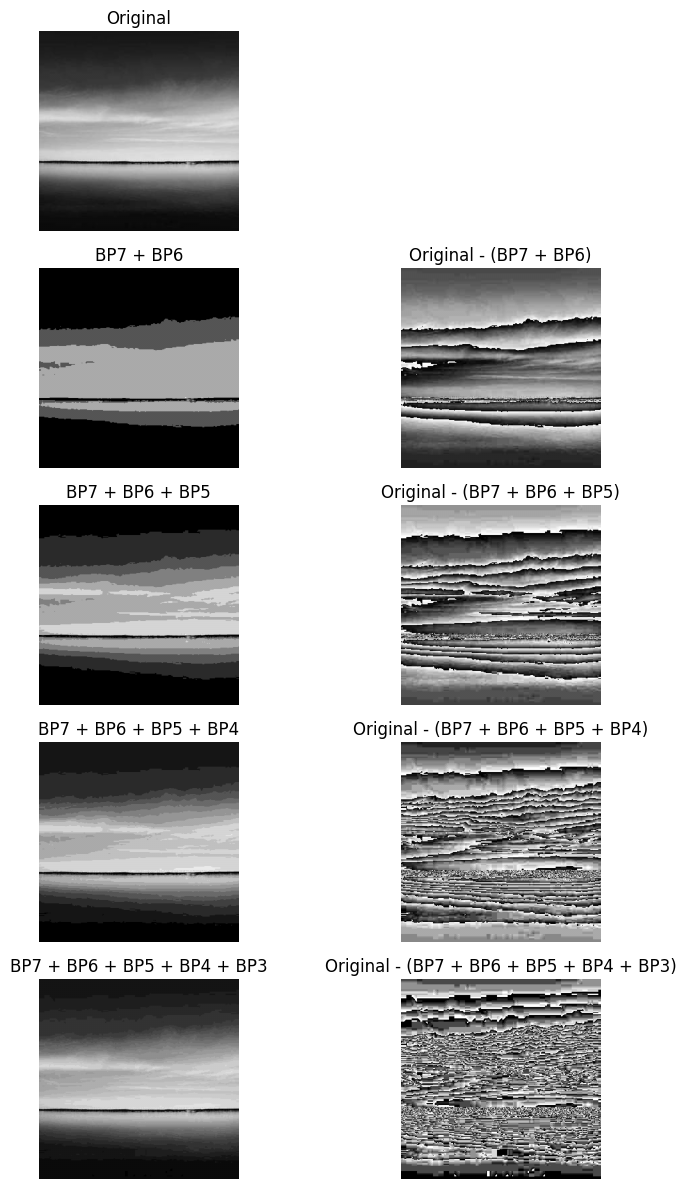

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("img1.jpg").convert("L")
img_np = np.array(img)

bit_planes = []

for b in range(8):
	plane = (img_np >> b) & 1
	bit_planes.append(plane)

rec1 = (bit_planes[7] << 7) + (bit_planes[6] << 6)
rec2 = rec1 + (bit_planes[5] << 5)
rec3 = rec2 + (bit_planes[4] << 4)
rec4 = rec3 + (bit_planes[3] << 3)

plt.figure(figsize=(8, 12))

# Row 1
plt.subplot(5, 2, 1)
plt.imshow(img_np, cmap="gray")
plt.title("Original")
plt.axis("off")

# Row 2
plt.subplot(5, 2, 3)
plt.imshow(rec1, cmap="gray")
plt.title("BP7 + BP6")
plt.axis("off")

plt.subplot(5, 2, 4)
plt.imshow(img_np - rec1, cmap="gray")
plt.title("Original - (BP7 + BP6)")
plt.axis("off")

# Row 3
plt.subplot(5, 2, 5)
plt.imshow(rec2, cmap="gray")
plt.title("BP7 + BP6 + BP5")
plt.axis("off")

plt.subplot(5, 2, 6)
plt.imshow(img_np - rec2, cmap="gray")
plt.title("Original - (BP7 + BP6 + BP5)")
plt.axis("off")

# Row 4
plt.subplot(5, 2, 7)
plt.imshow(rec3, cmap="gray")
plt.title("BP7 + BP6 + BP5 + BP4")
plt.axis("off")

plt.subplot(5, 2, 8)
plt.imshow(img_np - rec3, cmap="gray")
plt.title("Original - (BP7 + BP6 + BP5 + BP4)")
plt.axis("off")

# Row 5
plt.subplot(5, 2, 9)
plt.imshow(rec4, cmap="gray")
plt.title("BP7 + BP6 + BP5 + BP4 + BP3")
plt.axis("off")

plt.subplot(5, 2, 10)
plt.imshow(img_np - rec4, cmap="gray")
plt.title("Original - (BP7 + BP6 + BP5 + BP4 + BP3)")
plt.axis("off")

plt.tight_layout()
plt.show()

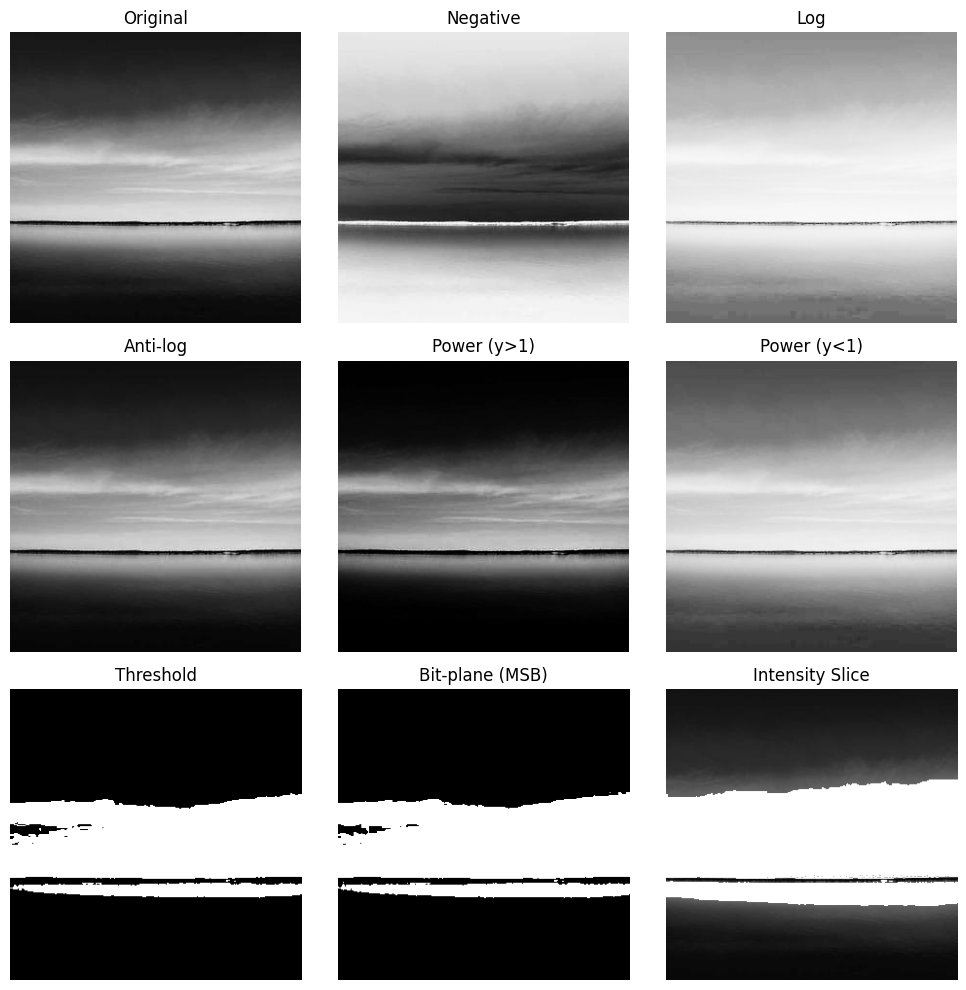

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("img1.jpg").convert("L")
img_np = np.array(img)

img_norm = img_np / 255.0

negative = 255 - img_np

c_log = 255 / np.log(1 + np.max(img_np))
log_img = c_log * np.log(1 + img_np)
log_img = log_img.astype(np.uint8)

antilog = np.exp(img_norm) - 1
antilog = (antilog / np.max(antilog)) * 255
antilog = antilog.astype(np.uint8)

gamma_high = 2.0
power_high = np.power(img_norm, gamma_high)
power_high = (power_high * 255).astype(np.uint8)

gamma_low = 0.5
power_low = np.power(img_norm, gamma_low)
power_low = (power_low * 255).astype(np.uint8)

threshold = 128
thresh_img = np.where(img_np > threshold, 255, 0).astype(np.uint8)

bit_plane7 = ((img_np >> 7) & 1) * 255

low, high = 100, 180
int_slice = np.where((img_np >= low) & (img_np <= high), 255, img_np).astype(np.uint8)

plt.figure(figsize=(10, 10))

titles = [
	"Original",
	"Negative",
	"Log",
	"Anti-log",
	"Power (y>1)",
	"Power (y<1)",
	"Threshold",
	"Bit-plane (MSB)",
	"Intensity Slice"
]

images = [
	img_np,
	negative,
	log_img,
	antilog,
	power_high,
	power_low,
	thresh_img,
	bit_plane7,
	int_slice
]

for i in range(9):
	plt.subplot(3, 3, i + 1)
	plt.imshow(images[i], cmap="gray")
	plt.title(titles[i])
	plt.axis("off")

plt.tight_layout()
plt.show()

# LAB - V

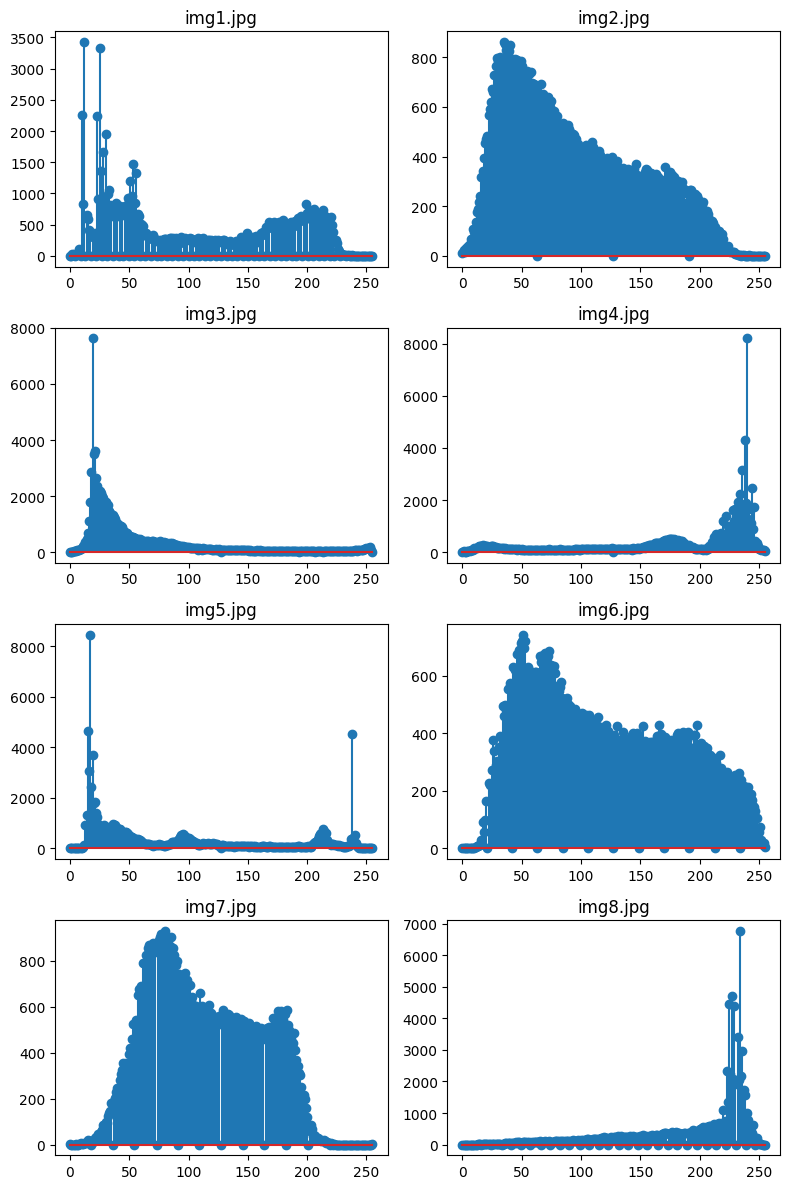

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(8, 12))

for i in range(8):
	# Load image
	img = Image.open(f'img{i+1}.jpg').convert('L')
	img = np.array(img)

	# Histogram (0–255)
	hist, bins = np.histogram(img, bins=256)

	# Subplot 4x2
	plt.subplot(4, 2, i + 1)

	# Stem plot
	plt.stem(hist)

	plt.title(f'img{i+1}.jpg')

plt.tight_layout()
plt.show()

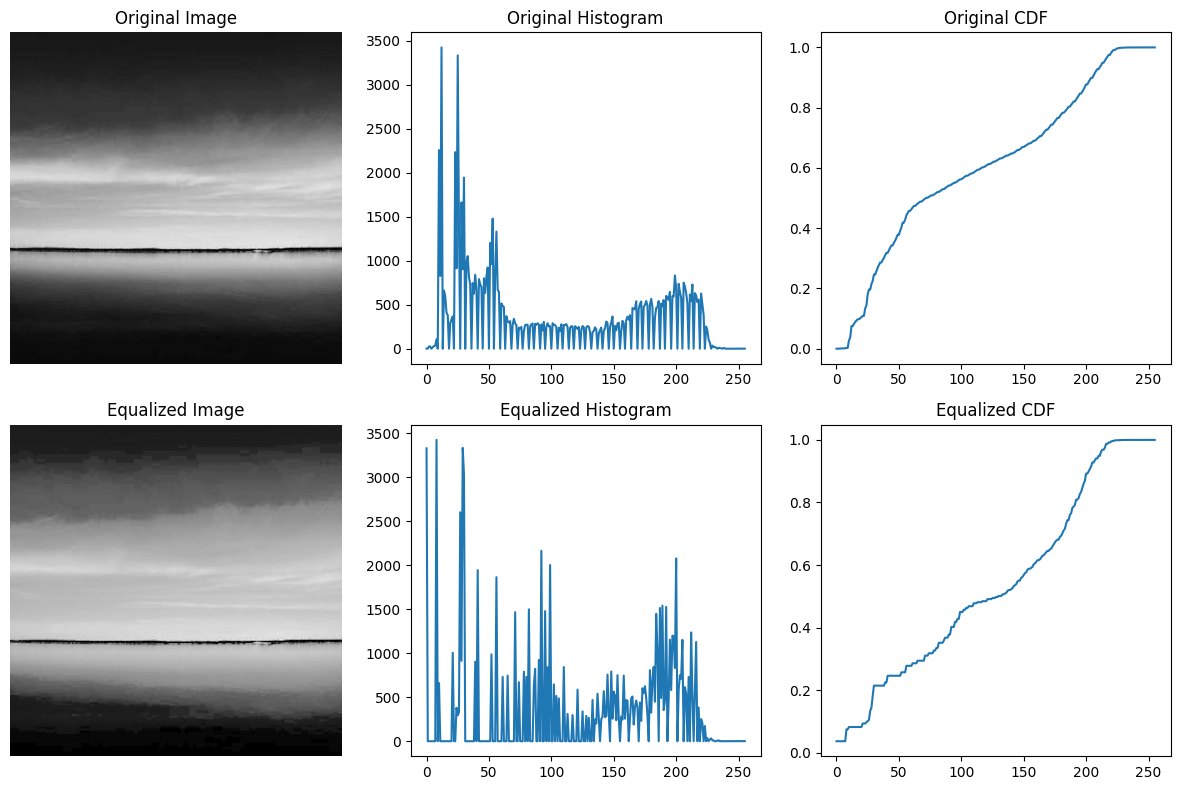

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
img = Image.open('img1.jpg').convert('L')
img = np.array(img)

L = 256

# --- Original Histogram ---
hist_orig, bins = np.histogram(img, bins=256)

# --- Original CDF ---
cdf_orig = hist_orig.cumsum()

cdf_norm = cdf_orig / img.size

# --- Histogram Equalization ---
S = ((L - 1) * cdf_norm).astype('uint8')

# Map pixels
img_eq = S[img]

# --- Equalized Histogram ---
hist_eq, bins = np.histogram(img_eq, bins=256)

# --- Equalized CDF ---
cdf_eq = hist_eq.cumsum()
cdf_eq_norm = cdf_eq / img.size

# --- Plot (2 x 3) ---
plt.figure(figsize=(12,8))

# Original Image
plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Original Histogram
plt.subplot(2,3,2)
plt.plot(hist_orig)
plt.title('Original Histogram')

# Original CDF
plt.subplot(2,3,3)
plt.plot(cdf_norm)
plt.title('Original CDF')

# Equalized Image
plt.subplot(2,3,4)
plt.imshow(img_eq, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

# Equalized Histogram
plt.subplot(2,3,5)
plt.plot(hist_eq)
plt.title('Equalized Histogram')

# Equalized CDF
plt.subplot(2,3,6)
plt.plot(cdf_eq_norm)
plt.title('Equalized CDF')

plt.tight_layout()
plt.show()

# LAB - VI

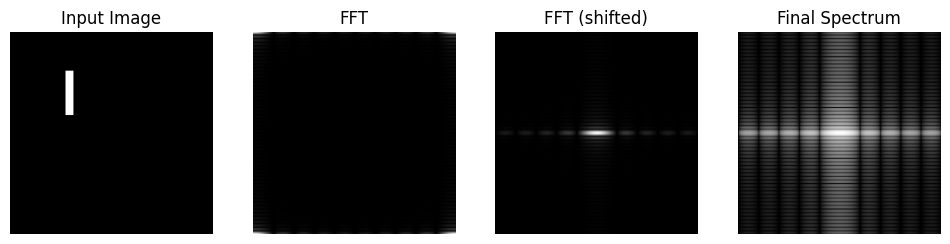

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create image
img = np.zeros((256, 256))
img[50:106, 70:80] = 1

# Step 2: Apply FFT
fft = np.abs(np.fft.fft2(img))
fft_shift = np.fft.fftshift(fft)
magnitude = 20 * np.log(1 + fft_shift)

# Step 3: Plot
plt.figure(figsize=(12,5))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title('Input Image')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(fft, cmap='gray')
plt.title('FFT')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(fft_shift, cmap='gray')
plt.title('FFT (shifted)')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(magnitude, cmap='gray')
plt.title('Final Spectrum')
plt.axis('off')

plt.show()

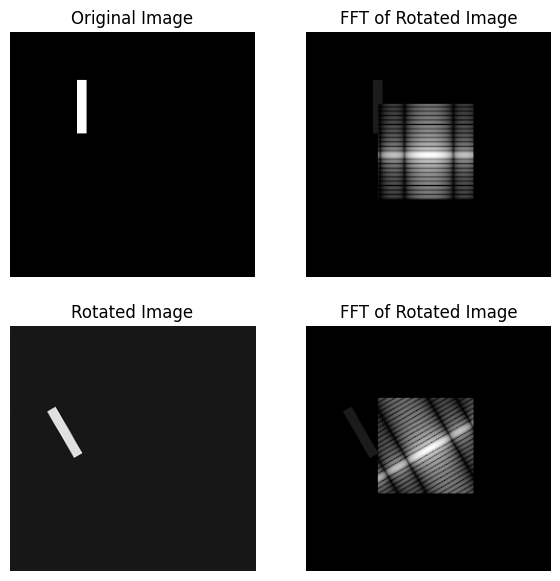

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

def box_filter_magnitude(img, x1 = 75, y1 = 75, x2 = 175, y2 = 175):
	# Step 1: FFT
	fft = np.fft.fft2(img)
	fft_shift = np.fft.fftshift(fft)

	rows, cols = fft_shift.shape

	mask = np.zeros((rows, cols))
	mask[y1:y2, x1:x2] = 1

	magnitude = np.log(1 + np.abs(img * (1 - mask) + fft_shift * mask))
	return magnitude

# Step 1: Create image
img = np.zeros((256, 256))
img[50:106, 70:80] = 1
rotated_img = rotate(img, angle=30, reshape=False)

# Step 2: Plot
plt.figure(figsize=(7,7))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(box_filter_magnitude(img), cmap='gray')
plt.title('FFT of Rotated Image')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(rotated_img, cmap='gray')
plt.title('Rotated Image')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(box_filter_magnitude(rotated_img), cmap='gray')
plt.title('FFT of Rotated Image')
plt.axis('off')

plt.show()

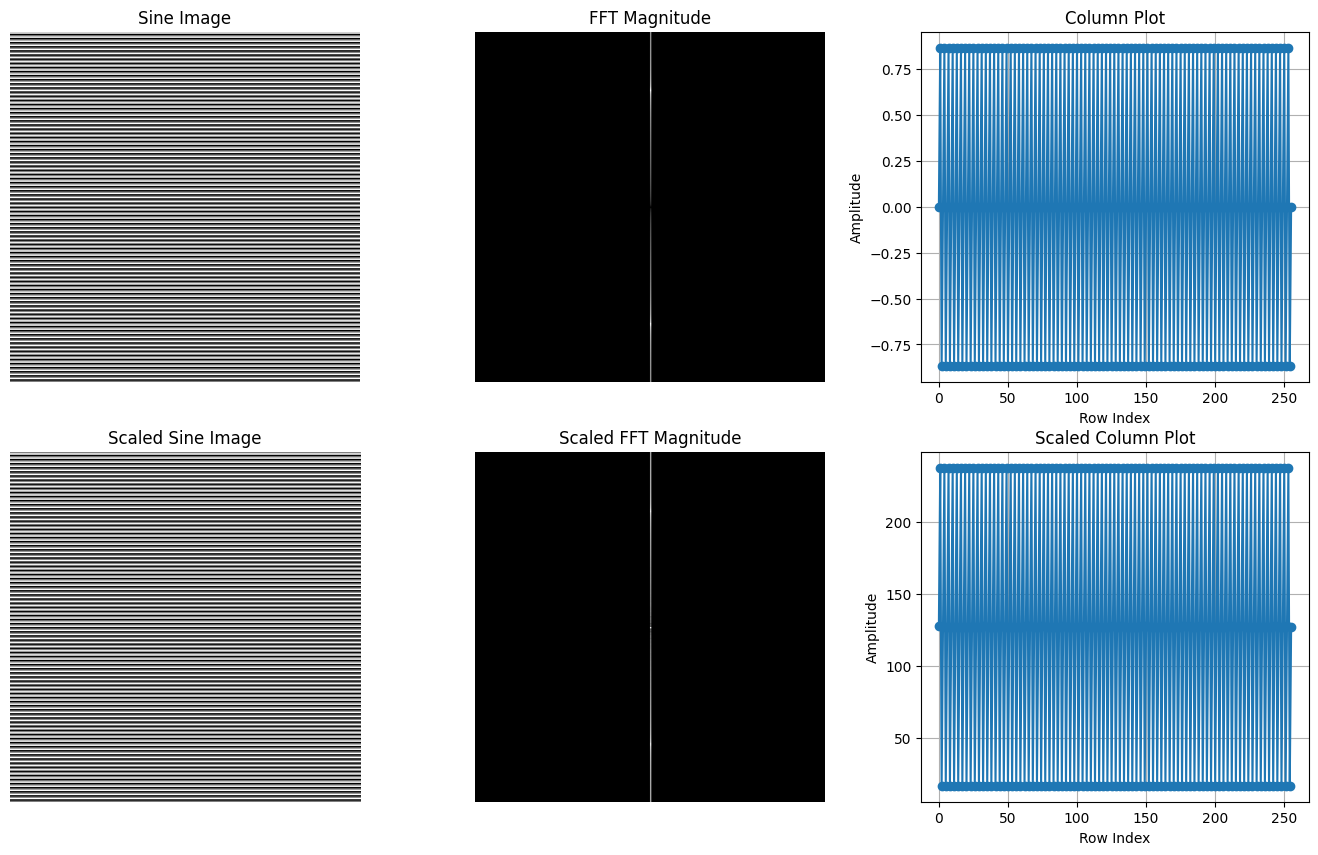

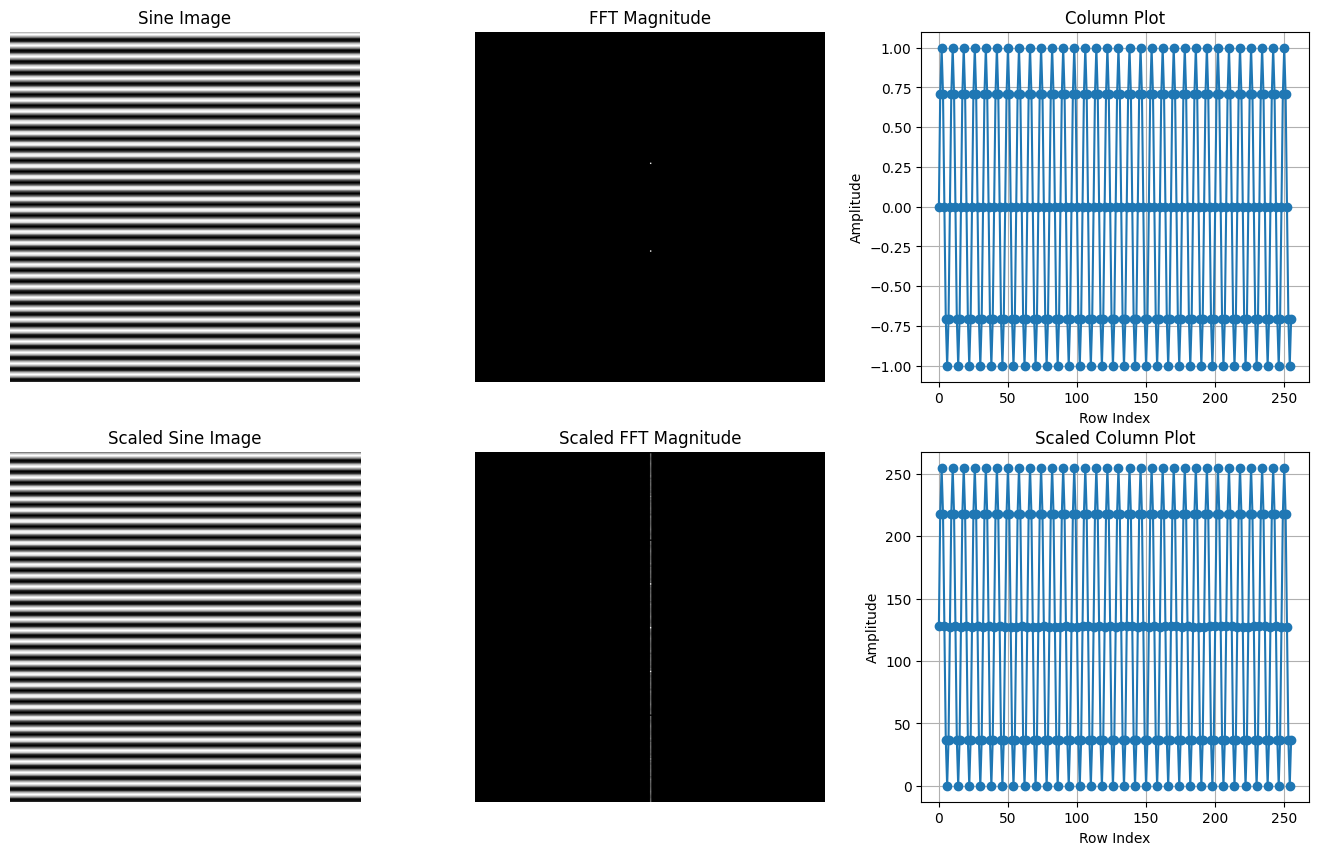

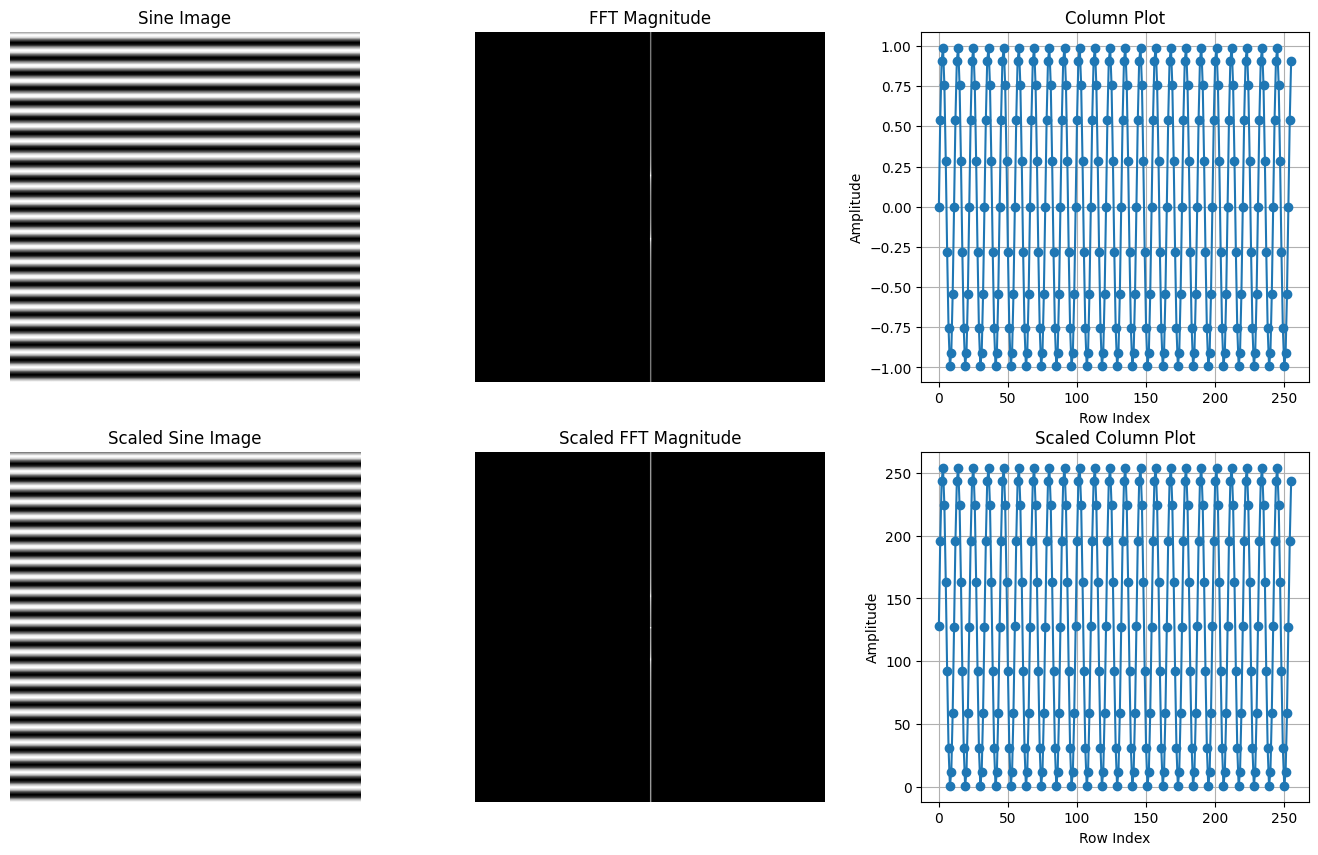

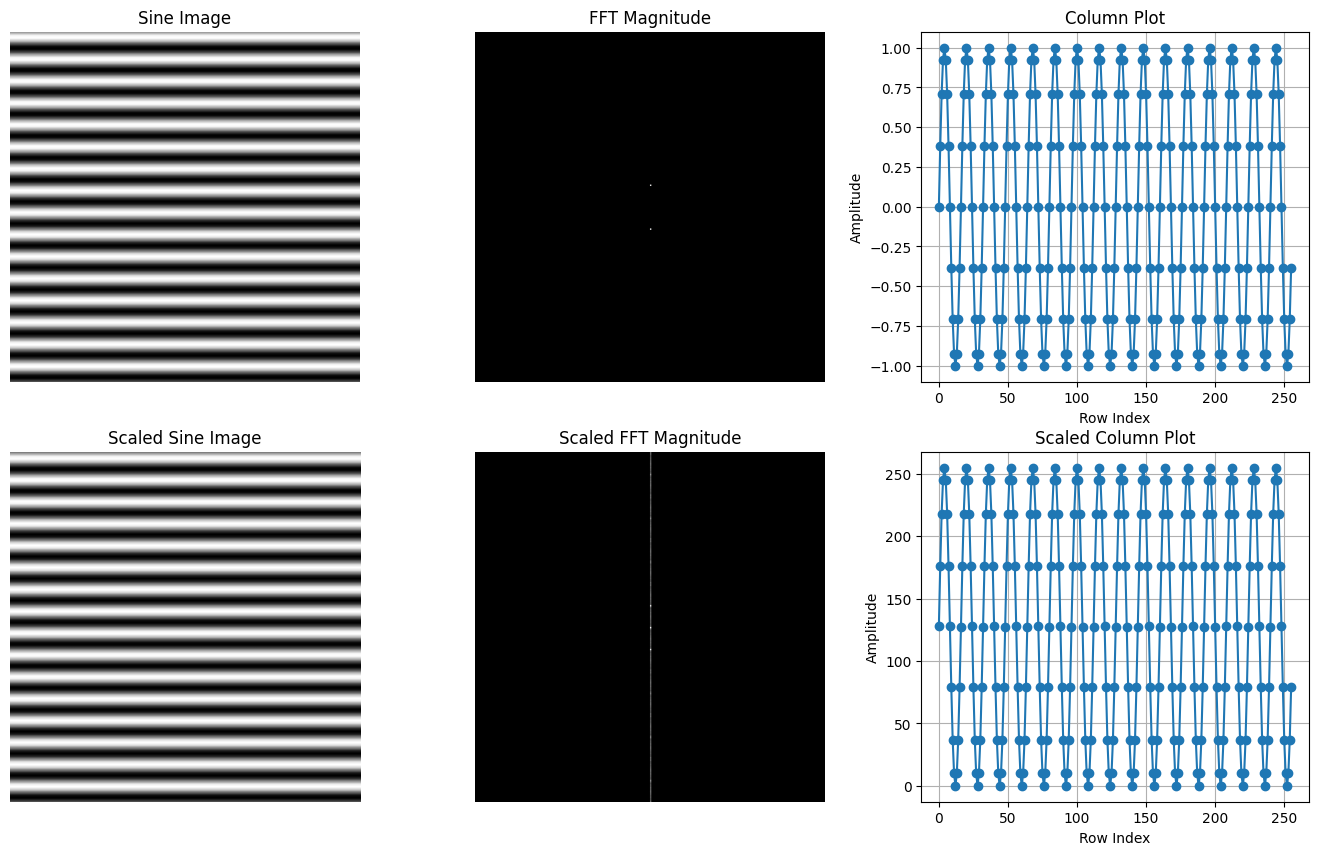

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def sine_transform(t):
	img = np.zeros((256, 256))
	rows, cols = img.shape
	result = np.zeros((rows, cols))

	for i in range(rows):
		for j in range(cols):
			result[i, j] = np.sin(2 * np.pi * i / t)

	result1 = np.round(255 * (result + 1) / 2)
	return result, result1

def fft(img):
	fft = np.abs(np.fft.fft2(img))
	fft_shift = np.fft.fftshift(fft)
	magnitude = 20 * np.log(1 + fft_shift)

	return magnitude

# Show images
def plot(t):
	img, img1 = sine_transform(t)

	plt.figure(figsize=(17,10))

	plt.subplot(2,3,1)
	plt.imshow(img, cmap='gray')
	plt.title('Sine Image')
	plt.axis('off')

	plt.subplot(2,3,2)
	plt.imshow(fft(img), cmap='gray')
	plt.title('FFT Magnitude')
	plt.axis('off')

	plt.subplot(2,3,3)
	plt.plot(img[:, 0], 'o-')
	plt.title('Column Plot')
	plt.xlabel('Row Index')
	plt.ylabel('Amplitude')
	plt.grid()

	plt.subplot(2,3,4)
	plt.imshow(img1, cmap='gray')
	plt.title('Scaled Sine Image')
	plt.axis('off')

	plt.subplot(2,3,5)
	plt.imshow(fft(img1), cmap='gray')
	plt.title('Scaled FFT Magnitude')
	plt.axis('off')

	plt.subplot(2,3,6)
	plt.plot(img1[:, 0], 'o-')
	plt.title('Scaled Column Plot')
	plt.xlabel('Row Index')
	plt.ylabel('Amplitude')
	plt.grid()

plot(3)
plot(8)
plot(11)
plot(16)